# 06 · Site Classification

**Input :** `data/processed/analysis_panel.parquet`
**Outputs:** `data/processed/analysis_panel.parquet` (updated) · `data/processed/site_classification.parquet`

Classify all well-covered AWV stations into **commuter**, **mixed**, or **leisure**
using two behavioural metrics:
1. Weekday / weekend ratio
2. Peak-hour share (avg peak_ratio)

> **Note on school holiday retention:** A 3-metric version was tested but discarded.
> Belgian school holidays overlap heavily with general vacation periods (summer,
> Christmas), so even commuter stations drop during holidays — opposite to the design
> assumption. A sensitivity analysis showed 19.5 % of stations changed category between
> the two versions, confirming the third metric was distorting rather than refining the
> classification. The 2-metric composite is simpler and more reliable.

Steps: 0 Load · 1 Metrics · 2 Normalise · 3 Classify · 4 Merge back ·
5 Validate · 6 Figures · 7 Save · 8 Summary

## 0. Imports & Load Data

In [79]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
panel["date"] = pd.to_datetime(panel["date"])

panel_good = panel[panel["low_coverage"] == False].copy()

n_total = panel["site ID"].nunique()
n_good  = panel_good["site ID"].nunique()
n_low   = n_total - n_good

print(f"Total stations        : {n_total}")
print(f"Well-covered stations : {n_good}")
print(f"Low-coverage stations : {n_low}")

Total stations        : 150
Well-covered stations : 133
Low-coverage stations : 17


## 1. Compute Station-Level Classification Metrics

Two metrics that proxy commute vs leisure behaviour:
- **Weekday/weekend ratio** — commuters keep cycling Mon–Fri, leisure cyclists peak on weekends
- **Peak-hour ratio** — commuters concentrate trips around 07–09h and 16–18h

In [80]:
# Base aggregation — avg_daily, avg_peak_ratio, lon, lat per station
base = (
    panel_good.groupby(["site ID", "naam", "gemeente"], as_index=False)
    .agg(
        avg_daily      = ("aantal",      "mean"),
        avg_peak_ratio = ("peak_ratio",  "mean"),
        lon            = ("long",         "first"),
        lat            = ("lat",         "first"),
    )
)

# Separate filtered groupbys (faster than per-group lambdas on 96k rows)
wd = (panel_good[~panel_good["is_weekend"]]
      .groupby("site ID")["aantal"].mean().rename("avg_weekday"))
we = (panel_good[ panel_good["is_weekend"]]
      .groupby("site ID")["aantal"].mean().rename("avg_weekend"))

site_stats = (
    base
    .merge(wd.reset_index(), on="site ID", how="left")
    .merge(we.reset_index(), on="site ID", how="left")
)

# Metric 1: weekday / weekend ratio
# Reference: https://ica-abs.copernicus.org/articles/1/37/2019/ica-abs-1-37-2019.pdf
site_stats["weekday_weekend_ratio"] = (
    site_stats["avg_weekday"] / site_stats["avg_weekend"]
)

print("Key metric distributions:")
desc_cols = ["weekday_weekend_ratio", "avg_peak_ratio"]
display(site_stats[desc_cols].describe().round(3))

Key metric distributions:


,weekday_weekend_ratio,avg_peak_ratio
count,133.000,133.000
mean,1.646,0.421
std,0.756,0.055
min,0.629,0.243
25%,1.341,0.384
50%,1.547,0.430
75%,1.744,0.456
max,7.563,0.540


## 2. Normalise and Score

In [81]:
metrics = ["weekday_weekend_ratio", "avg_peak_ratio"]
# Normalize to 0-1; more robust to outliers than z-scores for a bounded composite score
scaler  = MinMaxScaler()
site_stats[["norm_wwr", "norm_peak"]] = scaler.fit_transform(site_stats[metrics])

# Composite score: equal weights — both metrics are equally direct indicators of commuting behaviour
# Reference: https://ica-abs.copernicus.org/articles/1/37/2019/ica-abs-1-37-2019.pdf
site_stats["commute_score"] = (
    site_stats["norm_wwr"]  * 0.5 +
    site_stats["norm_peak"] * 0.5
)

print("commute_score distribution:")
print(site_stats["commute_score"].describe().round(3))

commute_score distribution:
count    133.000
mean       0.373
std        0.113
min        0.021
25%        0.305
50%        0.386
75%        0.434
max        0.920
Name: commute_score, dtype: float64


## 3. Classify Stations into Three Groups

Tertile split on `commute_score`:
- **commuter** — top third
- **mixed** — middle third
- **leisure** — bottom third

In [82]:
p33 = site_stats["commute_score"].quantile(0.33)
p67 = site_stats["commute_score"].quantile(0.67)

def classify(score):
    if score >= p67:   return "commuter"
    elif score >= p33: return "mixed"
    else:              return "leisure"

site_stats["site_type"] = site_stats["commute_score"].apply(classify)

print(f"Tertile thresholds : p33 = {p33:.3f}  |  p67 = {p67:.3f}")
print()
print("Stations per type:")
print(site_stats["site_type"].value_counts().sort_index())

SHOW_COLS = ["naam", "gemeente", "commute_score",
             "weekday_weekend_ratio", "avg_peak_ratio"]

print("Top 10 commuter stations:")
display(site_stats.nlargest(10, "commute_score")[SHOW_COLS].reset_index(drop=True).round(3))

print("Top 10 leisure stations:")
display(site_stats.nsmallest(10, "commute_score")[SHOW_COLS].reset_index(drop=True).round(3))

# Check Leuven Totem (site ID 107) rank
sorted_all  = site_stats.sort_values("commute_score", ascending=False).reset_index(drop=True)
sorted_all.index += 1
totem_rank  = sorted_all.index[sorted_all["site ID"] == 107][0]
print(f"Leuven Totem (site ID 107): rank #{totem_rank} out of {len(site_stats)}")
display(site_stats[site_stats["site ID"] == 107][SHOW_COLS + ["site_type"]].round(3))

Tertile thresholds : p33 = 0.338  |  p67 = 0.420

Stations per type:
site_type
commuter    44
leisure     44
mixed       45
Name: count, dtype: int64
Top 10 commuter stations:


,naam,gemeente,commute_score,weekday_weekend_ratio,avg_peak_ratio
0,Deinze teller 1,Nazareth,0.920,7.563,0.493
1,Mechelen teller 1,Mechelen,0.658,3.692,0.503
2,Zaventem totem,Zaventem,0.594,1.937,0.540
3,Herent teller 2,Herent,0.549,1.884,0.516
4,Gent,Gent,0.539,2.132,0.499
5,Wervik teller 2,Wervik,0.532,1.779,0.510
6,Wemmel teller 2,Wemmel,0.524,2.056,0.493
7,Grimbergen,Meise,0.519,1.695,0.506
8,Ieper totem,Ieper,0.514,1.741,0.500
9,Heist op den Berg 1,Heist-op-den-Berg,0.507,2.037,0.484


Top 10 leisure stations:


,naam,gemeente,commute_score,weekday_weekend_ratio,avg_peak_ratio
0,Maaseik teller 1,Maaseik,0.021,0.916,0.243
1,As,As,0.097,0.644,0.300
2,Heers teller 1,Heers,0.121,0.629,0.315
3,Heers,Heers,0.142,0.643,0.327
4,Nieuwpoort totem,Nieuwpoort,0.169,0.770,0.337
5,Lanaken teller 2,Lanaken,0.181,1.323,0.320
6,Houthalen-Helchteren,Houthalen-Helchteren,0.189,0.808,0.348
7,Maasmechelen teller 1,Maasmechelen,0.206,1.438,0.330
8,Westerlo teller 1,Westerlo,0.207,0.897,0.354
9,Nieuwpoort teller 1,Nieuwpoort,0.207,0.818,0.358


Leuven Totem (site ID 107): rank #62 out of 133


,naam,gemeente,commute_score,weekday_weekend_ratio,avg_peak_ratio,site_type
101,leuven totem,Leuven,0.395,1.492,0.441,mixed


## 4. Merge Classification Back to Panel

In [83]:
CLASS_COLS = ["site ID", "commute_score", "site_type",
              "weekday_weekend_ratio", "avg_peak_ratio"]

# Drop stale classification columns if panel was previously saved with them
stale_cols = [c for c in CLASS_COLS if c != "site ID"]
panel_good = panel_good.drop(columns=[c for c in stale_cols if c in panel_good.columns])
panel      = panel.drop(columns=[c for c in ["commute_score", "site_type"] if c in panel.columns])

panel_good = panel_good.merge(site_stats[CLASS_COLS], on="site ID", how="left")

panel_full = panel.merge(
    site_stats[["site ID", "commute_score", "site_type"]],
    on="site ID", how="left"
)
panel_full["site_type"] = panel_full["site_type"].fillna("unclassified")

print(f"panel_good shape : {panel_good.shape}")
print(f"panel_full shape : {panel_full.shape}")
print()
print("site_type distribution in panel_full:")
print(panel_full["site_type"].value_counts())

panel_good shape : (145768, 58)
panel_full shape : (164400, 56)

site_type distribution in panel_full:
site_type
mixed           49320
commuter        48224
leisure         48224
unclassified    18632
Name: count, dtype: int64


## 5. Validate Classification

In [84]:
TYPE_ORDER  = ["commuter", "mixed", "leisure"]
TYPE_COLORS = {"commuter": "steelblue", "mixed": "gold", "leisure": "tomato"}

wd_t = (panel_good[~panel_good["is_weekend"]]
        .groupby("site_type")["aantal"].mean().rename("avg_weekday"))
we_t = (panel_good[ panel_good["is_weekend"]]
        .groupby("site_type")["aantal"].mean().rename("avg_weekend"))
sd_t = (panel_good[~panel_good["is_school_holiday"]]
        .groupby("site_type")["aantal"].mean().rename("avg_schoolday"))
sh_t = (panel_good[ panel_good["is_school_holiday"]]
        .groupby("site_type")["aantal"].mean().rename("avg_schoolhol"))
pr_t = panel_good.groupby("site_type")["peak_ratio"].mean().rename("avg_peak_ratio")

val_table = (
    pd.concat([wd_t, we_t, sd_t, sh_t, pr_t], axis=1)
    .reindex(TYPE_ORDER)
)
val_table["wday_wend_ratio"] = (val_table["avg_weekday"] /
                                 val_table["avg_weekend"])
val_table["school_drop_pct"] = ((1 - val_table["avg_schoolhol"] /
                                      val_table["avg_schoolday"]) * 100)

print("Validation table by site_type:")
display(val_table.round(2))


Validation table by site_type:


,avg_weekday,avg_weekend,avg_schoolday,avg_schoolhol,avg_peak_ratio,wday_wend_ratio,school_drop_pct
site_type,,,,,,,
commuter,555.739990,324.160004,516.020020,424.739990,0.47,1.71,17.690001
mixed,612.150024,379.579987,565.940002,496.000000,0.42,1.61,12.360000
leisure,498.470001,417.510010,454.140015,527.320007,0.36,1.19,-16.110001


## 6. Visualisations

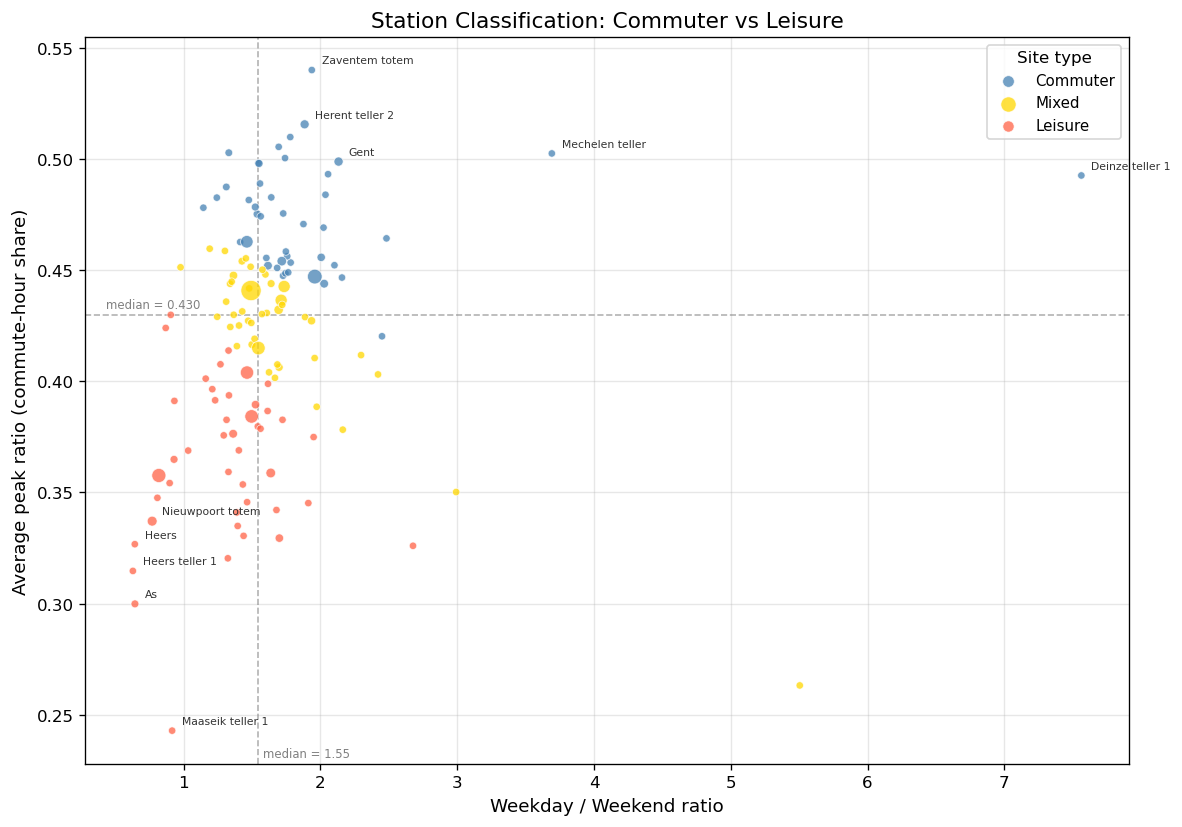

05_site_classification_scatter.png saved.


In [85]:
# ── scatter weekday_weekend_ratio vs avg_peak_ratio ────────────────────
med_wwr  = site_stats["weekday_weekend_ratio"].median()
med_peak = site_stats["avg_peak_ratio"].median()

fig, ax = plt.subplots(figsize=(10, 7))

for stype, color in TYPE_COLORS.items():
    sub = site_stats[site_stats["site_type"] == stype]
    ax.scatter(
        sub["weekday_weekend_ratio"], sub["avg_peak_ratio"],
        c=color, s=(sub["avg_daily"] / 30).clip(20, 300),
        alpha=0.75, label=stype.title(), edgecolors="white", lw=0.5, zorder=3,
    )

ax.axvline(med_wwr,  color="grey", lw=1, ls="--", alpha=0.6)
ax.axhline(med_peak, color="grey", lw=1, ls="--", alpha=0.6)
ax.text(med_wwr + 0.03, ax.get_ylim()[0] + 0.003,
        f"median = {med_wwr:.2f}", fontsize=7, color="grey")
ax.text(0.02, med_peak + 0.003,
        f"median = {med_peak:.3f}", fontsize=7, color="grey",
        transform=ax.get_yaxis_transform())

# Label top 5 commuter + top 5 leisure
for _, row in pd.concat([site_stats.nlargest(5, "commute_score"),
                          site_stats.nsmallest(5, "commute_score")]).iterrows():
    ax.annotate(
        row["naam"][:16],
        xy=(row["weekday_weekend_ratio"], row["avg_peak_ratio"]),
        fontsize=6.5, xytext=(6, 4), textcoords="offset points", color="#333",
    )

ax.set_xlabel("Weekday / Weekend ratio", fontsize=11)
ax.set_ylabel("Average peak ratio (commute-hour share)", fontsize=11)
ax.set_title("Station Classification: Commuter vs Leisure", fontsize=13)
ax.legend(title="Site type", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "05_site_classification_scatter.png", dpi=150)
plt.show()
print("05_site_classification_scatter.png saved.")

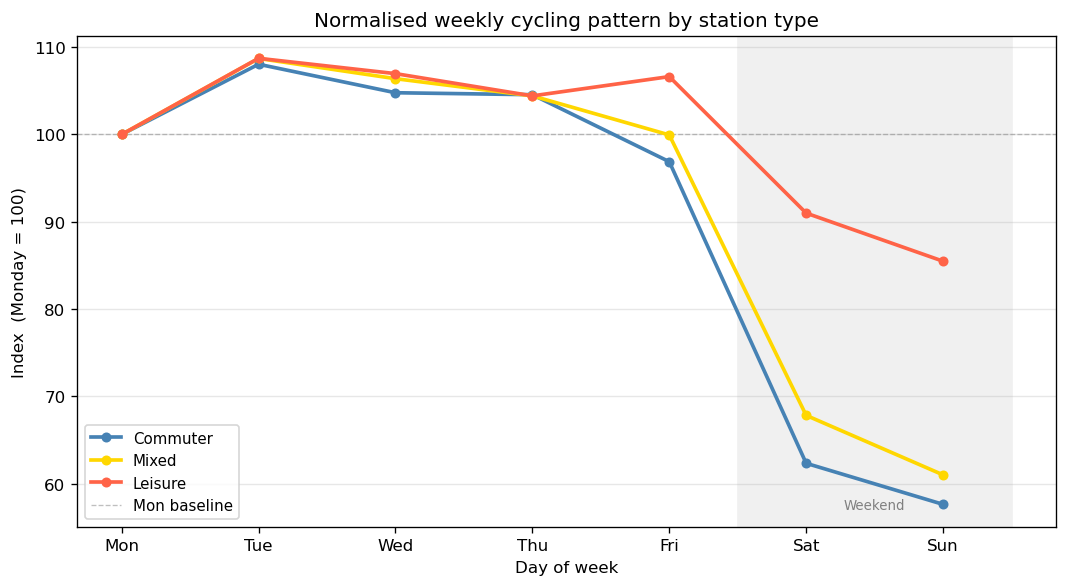

05_weekday_pattern_by_type.png saved.


In [86]:
# ── normalised weekly pattern by type ──────────────────────────────────
wd_pat = (
    panel_good.groupby(["site_type", "dayofweek"])["aantal"]
    .mean()
    .reset_index()
)

pivot = (
    wd_pat.pivot(index="dayofweek", columns="site_type", values="aantal")
    .reindex(columns=TYPE_ORDER)
)

# Index to Monday = 100 so shapes are comparable regardless of volume
# Every day/ Monday ratio shows relative pattern regardless of absolute volume differences
pivot_norm = pivot.div(pivot.loc[0]) * 100

DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(9, 5))
for stype, color in TYPE_COLORS.items():
    ax.plot(pivot_norm.index, pivot_norm[stype],
            color=color, lw=2.2, marker="o", ms=5, label=stype.title(), zorder=3)

ax.axhline(100, color="grey", lw=0.8, ls="--", alpha=0.5, label="Mon baseline")
ax.axvspan(4.5, 6.5, color="#f0f0f0", zorder=0)
ax.text(5.5, ax.get_ylim()[0] + 2, "Weekend", ha="center", fontsize=8, color="grey")
ax.set_xticks(range(7))
ax.set_xticklabels(DAY_LABELS)
ax.set_xlabel("Day of week")
ax.set_ylabel("Index  (Monday = 100)")
ax.set_title("Normalised weekly cycling pattern by station type")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "05_weekday_pattern_by_type.png", dpi=150)
plt.show()
print("05_weekday_pattern_by_type.png saved.")

/var/folders/99/f5nk7g8n09g1gdgwc7k9scjc0000gn/T/ipykernel_71488/525754679.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color="grey", alpha=0.4, hatch="//", edgecolor="grey", label="School holiday"),


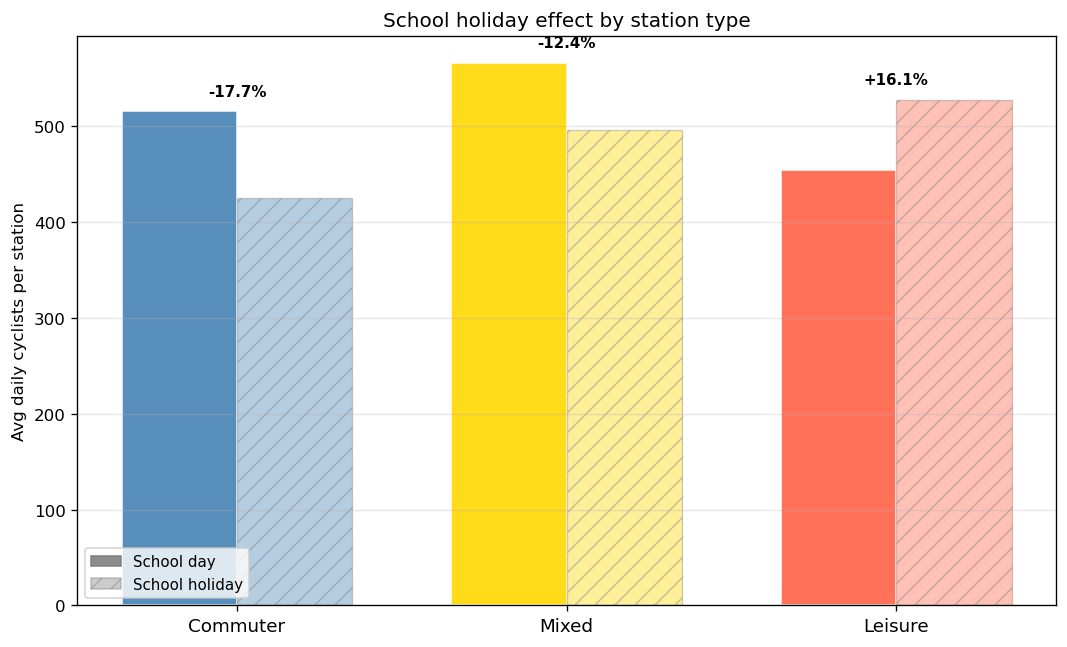

05_school_holiday_effect_by_type.png saved.


In [87]:
# ── school holiday effect by type ──────────────────────────────────────
school_avg = (
    panel_good.groupby(["site_type", "is_school_holiday"])["aantal"]
    .mean()
    .unstack()
    .rename(columns={False: "school_day", True: "school_holiday"})
    .reindex(TYPE_ORDER)
)
pct_change = ((school_avg["school_holiday"] - school_avg["school_day"])
              / school_avg["school_day"] * 100)

x     = np.arange(len(TYPE_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (stype, color) in enumerate(zip(TYPE_ORDER, ["steelblue", "gold", "tomato"])):
    ax.bar(x[i] - width / 2, school_avg.loc[stype, "school_day"],
           width, color=color, alpha=0.9, edgecolor="white")
    ax.bar(x[i] + width / 2, school_avg.loc[stype, "school_holiday"],
           width, color=color, alpha=0.4, edgecolor="grey", lw=0.8, hatch="//")

    # % change label above each pair
    y_top = max(school_avg.loc[stype, "school_day"],
                school_avg.loc[stype, "school_holiday"])
    sign  = "+" if pct_change[stype] >= 0 else ""
    ax.text(x[i], y_top * 1.025,
            f"{sign}{pct_change[stype]:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([t.title() for t in TYPE_ORDER], fontsize=11)
ax.set_ylabel("Avg daily cyclists per station")
ax.set_title("School holiday effect by station type")
ax.grid(axis="y", alpha=0.3)
legend_handles = [
    Patch(color="grey", alpha=0.9, label="School day"),
    Patch(color="grey", alpha=0.4, hatch="//", edgecolor="grey", label="School holiday"),
]
ax.legend(handles=legend_handles, fontsize=9, loc="lower left")
fig.tight_layout()
fig.savefig(FIGS / "05_school_holiday_effect_by_type.png", dpi=150)
plt.show()
print("05_school_holiday_effect_by_type.png saved.")

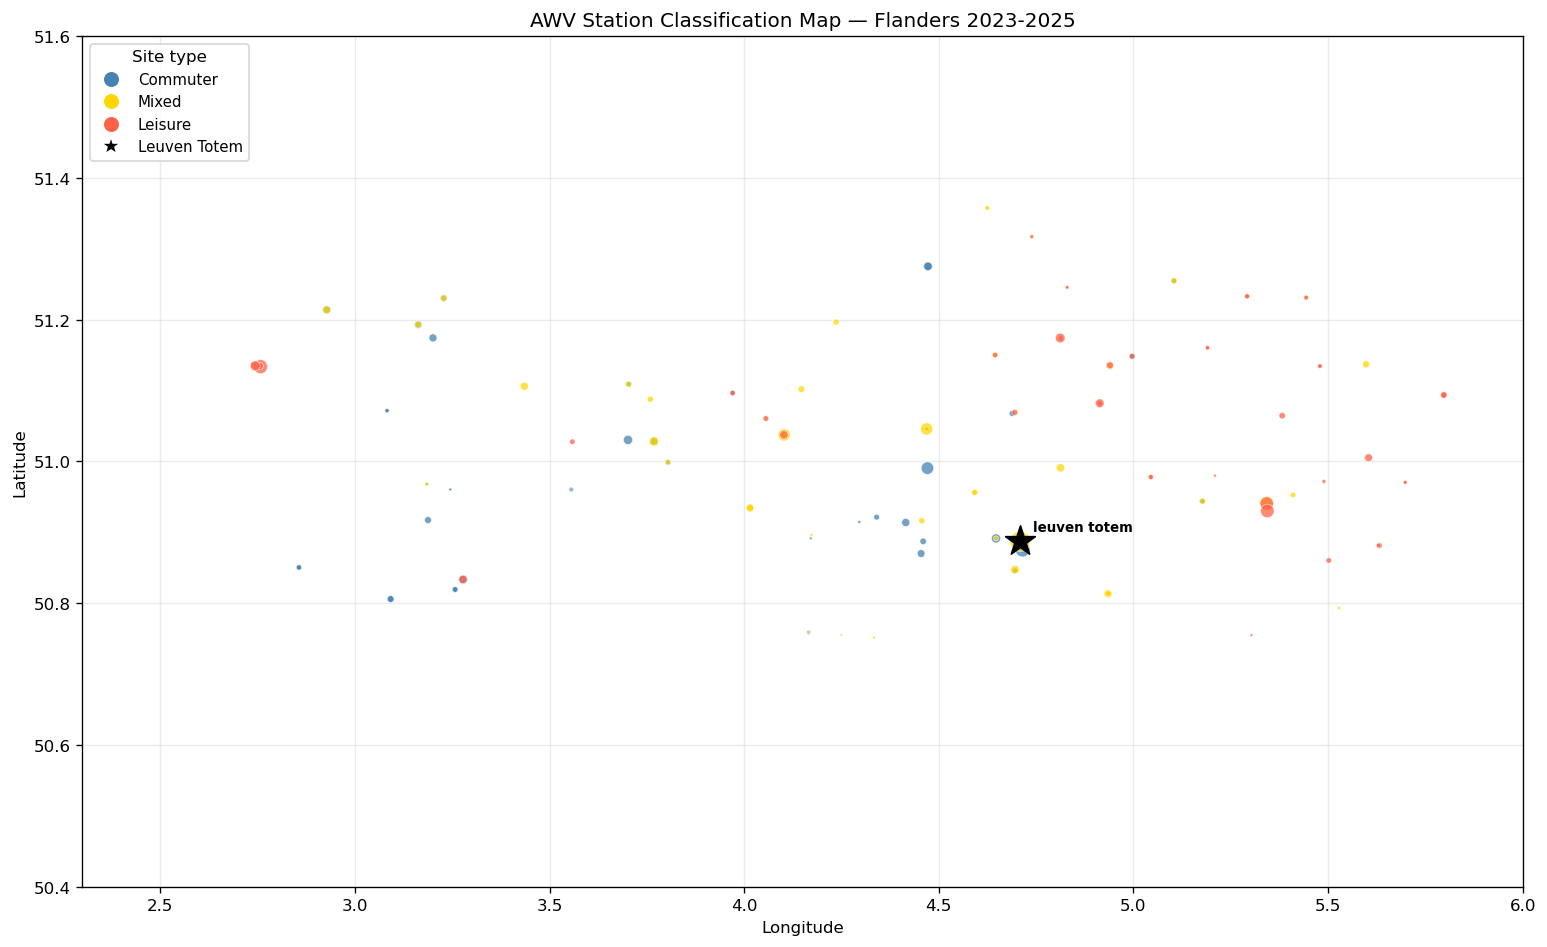

05_map_station_types.png saved.


In [88]:
# ── geographic map of station types ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

for stype, color in TYPE_COLORS.items():
    sub = site_stats[site_stats["site_type"] == stype]
    ax.scatter(
        sub["lon"], sub["lat"],
        c=color, s=sub["avg_daily"] / 30,
        alpha=0.75, zorder=3, edgecolors="white", lw=0.4,
    )

# Leuven Totem
totem = site_stats[site_stats["site ID"] == 107].iloc[0]
ax.scatter(totem["lon"], totem["lat"],
           marker="*", s=350, c="black", zorder=5)
ax.annotate("leuven totem",
            xy=(totem["lon"], totem["lat"]),
            xytext=(8, 6), textcoords="offset points",
            fontsize=8, fontweight="bold")

# Type legend
type_handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=c, markersize=10, label=t.title())
    for t, c in TYPE_COLORS.items()
]
type_handles.append(
    Line2D([0], [0], marker="*", color="w",
           markerfacecolor="black", markersize=12, label="Leuven Totem")
)
ax.legend(handles=type_handles, fontsize=9, title="Site type", loc="upper left")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("AWV Station Classification Map — Flanders 2023-2025", fontsize=12)
ax.set_xlim(2.3, 6.0)
ax.set_ylim(50.4, 51.6)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGS / "05_map_station_types.png", dpi=150)
plt.show()
print("05_map_station_types.png saved.")

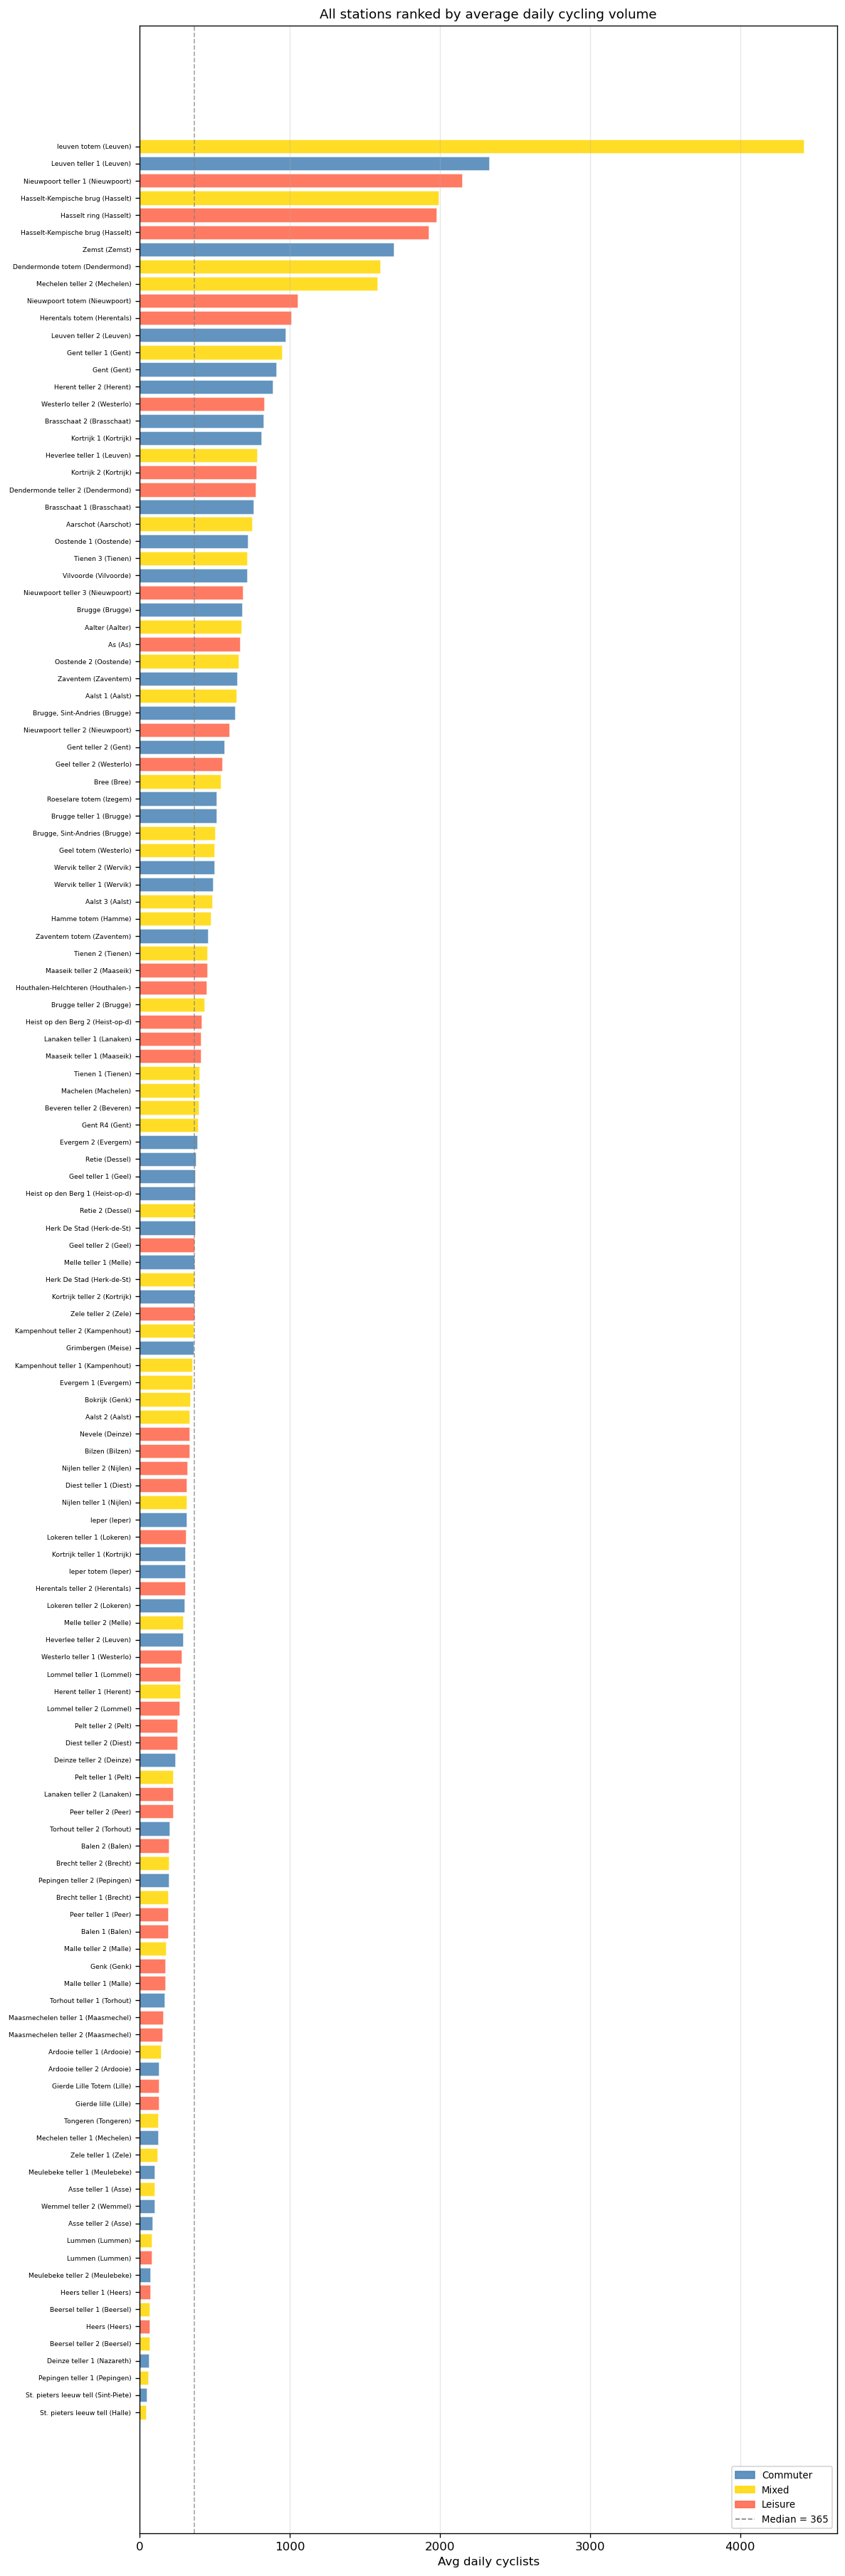

05_station_volume_ranking.png saved.


In [89]:
# ── station ranking by avg daily volume ────────────────────────────────────────
ranked = (
    site_stats[["naam", "gemeente", "avg_daily", "site_type"]]
    .sort_values("avg_daily", ascending=True)
    .reset_index(drop=True)
)

colors = ranked["site_type"].map(TYPE_COLORS)
fig, ax = plt.subplots(figsize=(10, len(ranked) * 0.22 + 1))

ax.barh(
    range(len(ranked)), ranked["avg_daily"],
    color=colors, alpha=0.85, edgecolor="white", lw=0.3,
)

labels = ranked["naam"].str[:22] + " (" + ranked["gemeente"].str[:10] + ")"
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(labels, fontsize=5.5)

med = ranked["avg_daily"].median()
ax.axvline(med, color="grey", lw=1, ls="--", alpha=0.7,
           label=f"Median = {med:.0f}")

legend_handles = [
    Patch(color=TYPE_COLORS[t], alpha=0.85, label=t.title())
    for t in ["commuter", "mixed", "leisure"]
] + [Line2D([0], [0], color="grey", lw=1, ls="--", label=f"Median = {med:.0f}")]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")

ax.set_xlabel("Avg daily cyclists", fontsize=10)
ax.set_title("All stations ranked by average daily cycling volume", fontsize=11)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "05_station_volume_ranking.png", dpi=150)
plt.show()
print("05_station_volume_ranking.png saved.")

## 7. Save Classification Results

In [90]:
site_stats.to_parquet(PROCESSED / "site_classification.parquet", index=False)

sz_class_kb = (PROCESSED / "site_classification.parquet").stat().st_size / 1024

print(f"site_classification.parquet saved")
print(f"  Shape     : {site_stats.shape}")
print(f"  Columns   : {list(site_stats.columns)}")
print(f"  File size : {sz_class_kb:.1f} KB")

site_classification.parquet saved
  Shape     : (133, 14)
  Columns   : ['site ID', 'naam', 'gemeente', 'avg_daily', 'avg_peak_ratio', 'lon', 'lat', 'avg_weekday', 'avg_weekend', 'weekday_weekend_ratio', 'norm_wwr', 'norm_peak', 'commute_score', 'site_type']
  File size : 18.4 KB


## 8. Summary

In [93]:
n_classified = len(site_stats)
type_ct      = site_stats["site_type"].value_counts()
n_low_cov    = panel["site ID"].nunique() - n_classified

totem       = site_stats[site_stats["site ID"] == 107].iloc[0]
sorted_s    = site_stats.sort_values("commute_score", ascending=False).reset_index(drop=True)
sorted_s.index += 1
totem_rank  = int(sorted_s.index[sorted_s["site ID"] == 107][0])

print("=" * 52)
print("SITE CLASSIFICATION SUMMARY")
print("=" * 52)
print(f"Total stations analysed : {n_classified} (well-covered only)")
print()
print("Classification results:")
for stype in ["commuter", "mixed", "leisure"]:
    n = type_ct.get(stype, 0)
    print(f"  {stype:<15} : {n:>3} stations ({n / n_classified * 100:.1f}%)")
print(f"  {'unclassified':<15} : {n_low_cov:>3} stations "
      f"(low-coverage, excluded)")
print()
print("Key metric averages by type:")
display(val_table.round(2))
print()
print(f"Leuven Totem (site ID 107):")
print(f"  commute_score         : {totem['commute_score']:.3f}"
      f"  (rank #{totem_rank}/{n_classified})")
print(f"  site_type             : {totem['site_type']}")
print(f"  weekday/weekend ratio : {totem['weekday_weekend_ratio']:.2f}")
print(f"  peak_ratio (avg)      : {totem['avg_peak_ratio']:.3f}")


SITE CLASSIFICATION SUMMARY
Total stations analysed : 133 (well-covered only)

Classification results:
  commuter        :  44 stations (33.1%)
  mixed           :  45 stations (33.8%)
  leisure         :  44 stations (33.1%)
  unclassified    :  17 stations (low-coverage, excluded)

Key metric averages by type:


,avg_weekday,avg_weekend,avg_schoolday,avg_schoolhol,avg_peak_ratio,wday_wend_ratio,school_drop_pct
site_type,,,,,,,
commuter,555.739990,324.160004,516.020020,424.739990,0.47,1.71,17.690001
mixed,612.150024,379.579987,565.940002,496.000000,0.42,1.61,12.360000
leisure,498.470001,417.510010,454.140015,527.320007,0.36,1.19,-16.110001



Leuven Totem (site ID 107):
  commute_score         : 0.395  (rank #62/133)
  site_type             : mixed
  weekday/weekend ratio : 1.49
  peak_ratio (avg)      : 0.441
